<a href="https://colab.research.google.com/github/Luseat/sistem_kelayakan_prediksi_kur/blob/main/pembuatan_model_random_forest_%26_bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Upload Dataset**

In [1]:
!pip install scikit-learn --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_Skripsi_RF_Final.xlsx to Dataset_Skripsi_RF_Final.xlsx


In [3]:
import pandas as pd

# Membaca dataset Excel
df = pd.read_excel('Dataset_Skripsi_RF_Final.xlsx')
df.head(25)

,usia,jenis_kelamin,status,omset,jumlah_pinjaman,tenor_pinjaman_(bulan),jumlah_anak,riwayat_telat_bayar,status_pinjaman
0,29,laki-laki,wirausaha,20000000,30000000,36,2,0,Approved
1,30,Perempuan,Wirausaha,15000000,100000000,36,0,0,Approved
2,27,Perempuan,Karyawan,148800000000,463450000000,144,2,0,Approved
3,40,Perempuan,Wirausaha,63550000000,189100000000,96,0,1,Rejected
4,49,Perempuan,Karyawan,141050000000,460350000000,240,3,1,Rejected
5,35,Perempuan,Karyawan,127100000000,475850000000,96,3,1,Rejected
6,31,Perempuan,Wirausaha,151900000000,375100000000,240,5,0,Rejected
7,28,Laki-laki,Wirausaha,74400000000,209250000000,120,0,0,Rejected
8,49,Laki-laki,Karyawan,134850000000,511500000000,48,5,0,Approved
9,41,Laki-laki,Wirausaha,88350000000,232500000000,240,2,1,Rejected


**Preprocessing**

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# 1 Load Data sesuaikan pemisahnya pakai titik koma ';'
df = pd.read_excel("Dataset_Skripsi_RF_Final.xlsx")


# Ubah menjadi huruf kecil semua
df['jenis_kelamin'] = df['jenis_kelamin'].str.lower()
df['status'] = df['status'].str.lower()

In [5]:
# 2 Ubah Target jadi Angka sesuai Flowchart: 0 = Approved, 1 = Reject(ed)
df['status_pinjaman'] = df['status_pinjaman'].map({'Approved': 0, 'Rejected': 1})


# Pisahin fitur (X) dan target (y)
X = df.drop('status_pinjaman', axis=1)
y = df['status_pinjaman']

In [6]:
# 3 Setting Preprocessing (Sesuai Metodologi Sistem)
numeric_features = ['usia', 'omset', 'jumlah_pinjaman', 'tenor_pinjaman_(bulan)', 'jumlah_anak', 'riwayat_telat_bayar']
categorical_features = ['jenis_kelamin', 'status']


# Preprocessing Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), #Handling Missing Value
    ('scaler', StandardScaler()) #Standarisasi scala seimbang
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))# encoding -> kategory
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [7]:
df.head(15)

,usia,jenis_kelamin,status,omset,jumlah_pinjaman,tenor_pinjaman_(bulan),jumlah_anak,riwayat_telat_bayar,status_pinjaman
0,29,laki-laki,wirausaha,20000000,30000000,36,2,0,0
1,30,perempuan,wirausaha,15000000,100000000,36,0,0,0
2,27,perempuan,karyawan,148800000000,463450000000,144,2,0,0
3,40,perempuan,wirausaha,63550000000,189100000000,96,0,1,1
4,49,perempuan,karyawan,141050000000,460350000000,240,3,1,1
5,35,perempuan,karyawan,127100000000,475850000000,96,3,1,1
6,31,perempuan,wirausaha,151900000000,375100000000,240,5,0,1
7,28,laki-laki,wirausaha,74400000000,209250000000,120,0,0,1
8,49,laki-laki,karyawan,134850000000,511500000000,48,5,0,0
9,41,laki-laki,wirausaha,88350000000,232500000000,240,2,1,1


**Split Data Training dan Testing (80:20)**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Data berhasil di-load dan siapa diproses...")
print(f"Jumlah data training: {X_train.shape[0]}, Jumlah data testing: {X_test.shape[0]}")



Data berhasil di-load dan siapa diproses...
Jumlah data training: 3416, Jumlah data testing: 855


**Model Random Forest**

In [9]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

**Model Bagging Pakai Decision Tree sebagai base modelnya**

In [10]:
bagging_classifier = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)

**Model Voting (Mekanisme Majority Voting / Hard Voting suara terbanyak)**

Hard voting → setiap model memberi prediksi kelas, lalu hasil akhir ditentukan dengan mayoritas suara.

Soft voting → setiap model memberi probabilitas prediksi, lalu probabilitas digabungkan dan dipilih kelas dengan skor tertinggi.

In [11]:
Voting_classifier = VotingClassifier(
    estimators=[
        ('Random Forest', rf_classifier),
        ('Bagging', bagging_classifier)
    ],
    voting='hard' # 'hard' voting untuk majority rule
)

**Bikin pipeline utuh dari Preprocessing sampai Model untuk ketiga sistem**

In [12]:
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('model', rf_classifier)])
pipeline_bagging = Pipeline(steps=[('preprocessor', preprocessor), ('model', bagging_classifier)])
pipeline_voting = Pipeline(steps=[('preprocessor', preprocessor), ('model', Voting_classifier)])

**Latih semua model (Training)**

In [13]:
pipeline_rf.fit(X_train, y_train)
pipeline_bagging.fit(X_train, y_train)
pipeline_voting.fit(X_train, y_train)

print("Semua model selesai dilatih...")

Semua model selesai dilatih...


**Fungsi untuk nge-test dan cetak hasil akurasi**

In [14]:
def evaluasi_model(nama_model, pipeline, X_test_data, y_test_data):
    y_pred = pipeline.predict(X_test_data)
    akurasi = accuracy_score(y_test_data, y_pred)
    print(f"=== Kinerja Model: {nama_model} ===")
    print(f"Akurasi: {akurasi * 100:.2f}%")
    print("Confusion Matrix:\n", confusion_matrix(y_test_data, y_pred))
    print("Classification Report:\n", classification_report(y_test_data, y_pred))
    print("-" * 50)

**Cek kinerja masing-masing model**

In [15]:
evaluasi_model("Random Forest", pipeline_rf, X_test, y_test)
evaluasi_model("Bagging", pipeline_bagging, X_test, y_test)
evaluasi_model("Voting Classifier (Hasil Akhir)", pipeline_voting, X_test, y_test)

=== Kinerja Model: Random Forest ===
Akurasi: 77.78%
Confusion Matrix:
 [[467  62]
 [128 198]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.88      0.83       529
           1       0.76      0.61      0.68       326

    accuracy                           0.78       855
   macro avg       0.77      0.75      0.75       855
weighted avg       0.78      0.78      0.77       855

--------------------------------------------------
=== Kinerja Model: Bagging ===
Akurasi: 76.73%
Confusion Matrix:
 [[460  69]
 [130 196]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.87      0.82       529
           1       0.74      0.60      0.66       326

    accuracy                           0.77       855
   macro avg       0.76      0.74      0.74       855
weighted avg       0.76      0.77      0.76       855

--------------------------------------------------
=== Kinerja 

77% buat kasus prediksi risiko kredit (Credit Scoring) di dunia nyata itu sangat realistis dan wajar. Kalau untuk penelitian angka segini jauh lebih bisa dipercaya dan gampang dipertanggungjawabkan pas sidang, daripada tiba-tiba mendapatkan akurasi 98% yang biasanya dapat dicurigai overfitting atau datanya bocor.

**Mengapa Demikian begitu?**

Akurasi 77%: Artinya dari semua tebakan modelnya 77% tebakannya udah bener. Buat data finansial/manusia yang perilakunya susah ditebak, ini angka yang solid sebagai baseline penelitian.
Hasil antar model stabil: Random Forest (77.78%), Bagging (76.73%), dan Voting (77.66%) hasilnya mirip-mirip. Artinya model ini cukup stabil dan nggak ngawur.

# **Poin Plus pada hasil dalam penelitian ini : mengenai soal metrik Recall di Class 1 (Reject)**


Perhatiin di Classification Report, bagian recall untuk label 1 (Reject) angkanya sekitar 0.59 - 0.61 (59% - 61%).
**Artinya secara bisnis:** Dari 100 calon debitur yang aslinya bakal gagal bayar (berisiko), model ini berhasil nangkap/nge-reject 61 orang, tapi 39 orang sisanya lolos (dikira aman).

Sebaliknya, recall buat label 0 (Approved) tinggi banget ~0.88 (88%). Artinya model lu jago banget ngenalin orang yang emang bayarnya lancar.

**Visualisasi Confusion Matrix Heatmap**

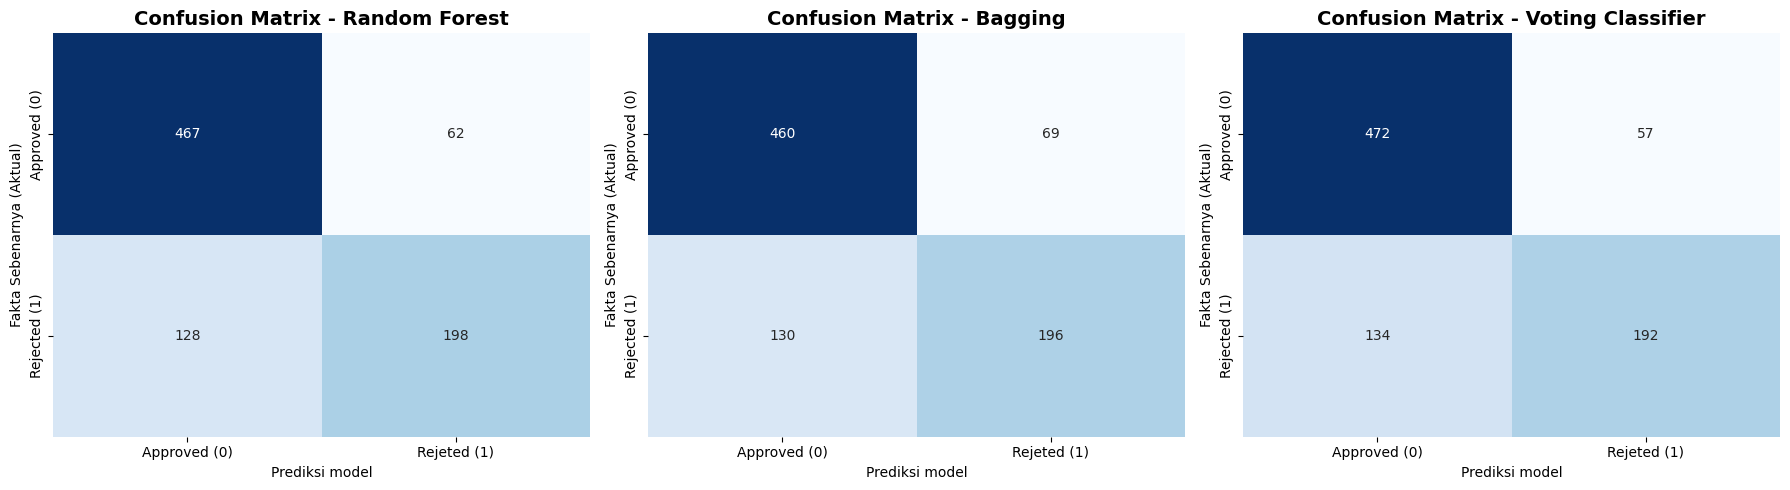

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns


# Canvas buat 3 gambar sejajar
fig, axs = plt.subplots(1, 3, figsize=(18,5))
models = [
    ("Random Forest", pipeline_rf),
    ("Bagging", pipeline_bagging),
    ("Voting Classifier", pipeline_voting)
]


for i, (nama, model) in enumerate(models):
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)


  #Bikin Headmap
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[i], cbar=False,
              xticklabels=['Approved (0)', 'Rejeted (1)'],
              yticklabels=['Approved (0)', 'Rejected (1)'])
  axs[i].set_title(f'Confusion Matrix - {nama}', fontsize=14, fontweight='bold')
  axs[i].set_xlabel('Prediksi model')
  axs[i].set_ylabel('Fakta Sebenarnya (Aktual)')


plt.tight_layout()
plt.show()

HEADMAP

Hasilanya adalah kalau kotak pojok kanan atas itu jumlah orang yang harusnya Approved tapi ketebak Reject (hati-hati buat bank kehilangan cuan), dan kotak kiri bawah itu orang yang harusnya Reject tapi ketebak Approved (berpotensi bikin kredit macet)

**Visualisasi Feature Importance (Tingkat Kepentingan Faktor)**

/tmp/ipykernel_2723/1225685399.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_urut, y=fitur_urut, palette='viridis')


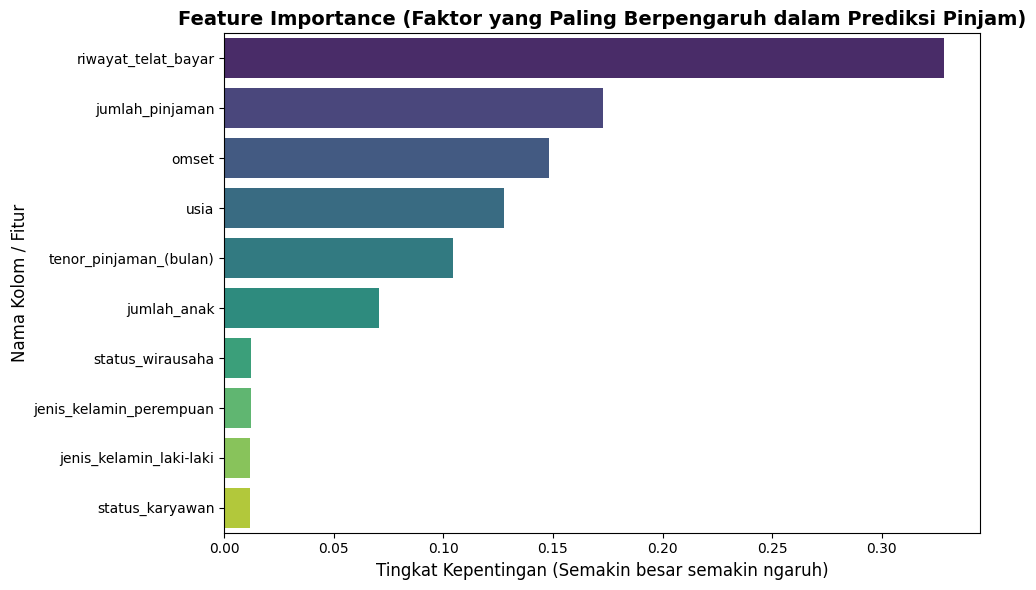

In [17]:
# Ekstrak nama fitur asli setelah di-preprocessing (One-Hot Encoding dll)
preprocessor_step = pipeline_rf.named_steps['preprocessor']
num_cols = numeric_features


#Fitur teks yang udh di-encode (jenis_kelamin & status)
one_step = preprocessor_step.transformers_[1][1].named_steps['onehot']
cat_cols = one_step.get_feature_names_out(categorical_features)
semua_fitur = np.concatenate([num_cols, cat_cols]) # Gabung semua fitur


# Ambil nilai 'kepentingan' dari model Random Forest
importances = pipeline_rf.named_steps['model'].feature_importances_


#Dari yang paling penting
indices = np.argsort(importances)[::-1]
fitur_urut = semua_fitur[indices]
importance_urut = importances[indices]


plt.figure(figsize=(10, 6))
sns.barplot(x=importance_urut, y=fitur_urut, palette='viridis')
plt.title('Feature Importance (Faktor yang Paling Berpengaruh dalam Prediksi Pinjam)', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan (Semakin besar semakin ngaruh)', fontsize=12)
plt.ylabel('Nama Kolom / Fitur', fontsize=12)
plt.tight_layout()
plt.show()


kolom riwayat_telat_bayar, jumlah_pinjaman, serta omset ada di paling atas, jadi berdasarkan algoritma Random Forest, riwayat masa lalu dan pendapatan nasabah jadi penentu utama sistem menolak pinjaman

**Bar Chart Perbandingan Akurasi Antar Model**

/tmp/ipykernel_2723/2113103480.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x=[m[0] for m in models], y=akurasis, palette='magma')


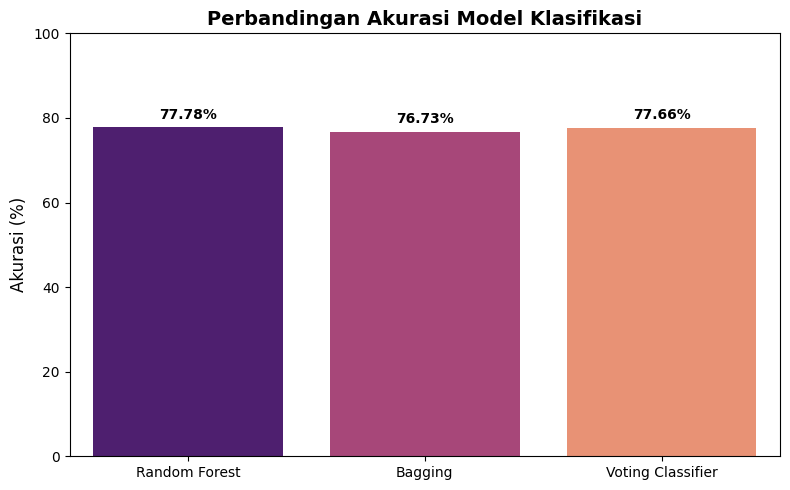

In [18]:
akurasis = []
for nama, model in models:
  acc = accuracy_score(y_test, model.predict(X_test)) * 100
  akurasis.append(acc)


# Bar Chart
plt.figure(figsize=(8, 5))
bar_plot = sns.barplot(x=[m[0] for m in models], y=akurasis, palette='magma')


#tambah label angka persis di atas tiap batan
for p in bar_plot.patches:
  bar_plot.annotate(format(p.get_height(), '.2f') + '%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontweight = 'bold')


plt.title('Perbandingan Akurasi Model Klasifikasi', fontsize=14, fontweight='bold')
plt.ylabel('Akurasi (%)', fontsize=12)
plt.ylim(0, 100)# Biar skala y mentok di 100%
plt.tight_layout()
plt.show()

**SMOTE + Hyperparameter Tuning (GridSearchCV)**

In [19]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier


pipeline_rf_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor), # Step 1 Bersihin & Standarisasi
    ('smote', SMOTE(random_state=42)),# Step 2 Seimbangin data Approved vs Reject
    ('model', RandomForestClassifier(random_state=42))# Step 3 Algoritma
])


pipeline_bagging_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),random_state=42))
])

Bikin Pipeline Baru (Khusus SMOTE)

penelitian ini pakai Pipeline dari 'imblearn' (bukan 'sklearn') biar SMOTE jalan aman dan nggak bocor ke data testing

**Tentukan Hyperparameter yang mau di-Tuning**

In [20]:
param_grid = {
    'model__n_estimators': [100, 200], # Jumlah pohon keputusannya
    'model__max_depth': [None, 10, 20], # Kedalaman maksimal pohon
    'model__min_samples_split': [2, 5], # Batas min. data buat mecah cabang
    'model__min_samples_leaf': [1,2]  # Batas min. data di ujung daun
}


param_grid_bagging = {
    'model__n_estimators': [50, 100, 150],  # Jumlah pohonnya
    'model__max_samples': [0.8, 1.0],       # Porsi sampel tiap pohon
    'model__max_features': [0.8, 1.0]       # Porsi fitur tiap pohon
}

Untuk param_grid itu menentukan Hyperparameter yang mau di-Tuning
Komputer bakal nyobain semua kombinasi angka di atas ini buat nyari yang paling top

**Setup GridSearchCV**

In [21]:
print("Mulai proses tuning & SMOTE...")
grid_search = GridSearchCV(
    pipeline_rf_smote,
    param_grid=param_grid,
    cv=5,                # Ujian silang (Cross-Validation) dibagi 5 bagian
    scoring='accuracy', # Target utamanya nyari 'Akurasi' tertinggi
    n_jobs=-1           # Pake semua tenaga prosesor (CPU) biar cepet selesai
)


grid_search_bagging = GridSearchCV(
    estimator=pipeline_bagging_smote,
    param_grid=param_grid_bagging,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

Mulai proses tuning & SMOTE...


**Training Data**

In [22]:
grid_search.fit(X_train, y_train)

print("=== PROSES SELESAI ===")
print("Ternyata Settingan Random Forest Parameter Terbaiknya adalah:", grid_search.best_params_)
print("-" * 50)


grid_search_bagging.fit(X_train, y_train)
print("=== PROSES SELESAI ===")
print("Ternyata Settingan Bagging Parameter Terbaiknya adalah:", grid_search_bagging.best_params_)
print("-" * 50)

=== PROSES SELESAI ===
Ternyata Settingan Random Forest Parameter Terbaiknya adalah: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}
--------------------------------------------------
=== PROSES SELESAI ===
Ternyata Settingan Bagging Parameter Terbaiknya adalah: {'model__max_features': 0.8, 'model__max_samples': 0.8, 'model__n_estimators': 50}
--------------------------------------------------


**Evaluasi Kinerja Model Hasil Tuning Ini**

In [23]:
# Ambil otak/model utamanya aja dari hasil tuning yang tadi (tanpa preprocessornya)
best_model_rf = grid_search.best_estimator_.named_steps['model']
best_model_bagging = grid_search_bagging.best_estimator_.named_steps['model']


#Bikin sistem Voting dari kedua otak terbaik tersebut
best_voting_clf = VotingClassifier(
    estimators=[
        ('Random Forest Tuned', best_model_rf),
        ('Bagging Tuned', best_model_bagging)
    ],
    voting='hard'
)


pipeline_voting_final = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', best_voting_clf)
])


# Masukin ke dalam Pipeline akhir (Grand Final)
pipeline_voting_final.fit(X_train, y_train)


# Evaluasi Model Finalnya
y_pred_final = pipeline_voting_final.predict(X_test)
akurasi_final = accuracy_score(y_test, y_pred_final)


print("\n=== KINERJA MODELL (FINAL) ===")
print(f"Akurasi: {akurasi_final * 100:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("Classification Report:\n", classification_report(y_test, y_pred_final))


=== KINERJA MODELL (FINAL) ===
Akurasi: 78.25%
Confusion Matrix:
 [[475  54]
 [132 194]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.90      0.84       529
           1       0.78      0.60      0.68       326

    accuracy                           0.78       855
   macro avg       0.78      0.75      0.76       855
weighted avg       0.78      0.78      0.78       855



**Kenapa Hasilnya Gak Beda Jauh?**

Kalo di compare angkanya:

Akurasi Awal: 77.78%
→ Setelah Tuning: 78.28% (Naik dikit 0.5%)
Tebakan Salah (False Positive): Turun dari 62 jadi 54 Model jadi lebih jarang salah nolak orang yang aslinya aman.
Kenapa naiknya dikit? Dalam Machine Learning, akurasi itu ngga bisa dipaksa naik sampai 95% cuma dengan tuning kalau informasi dari datanya memang udah mentok segitu. Fitur yang dimasukin (usia, omset, tenor) mungkin mentok ngasih pola prediksi di angka 78%.

 Pada penelitian ini membuktikan bahwa model default Random Forest dari awal sudah sangat kuat/optimal menghadapi dataset ini, sehingga proses tuning hanya memberikan penyempurnaan kecil untuk mengurangi error (False Positive)

Tujuan SMOTE di sini bukan cuma mengejar Akurasi total, tapi untuk menaikkan nilai Recall pada kelas Reject (1). Dalam kasus pinjaman bank, kita lebih baik salah menolak orang yang sebenarnya mampu bayar, daripada kita meloloskan orang yang ternyata ujungnya Gagal Bayar (Kredit Macet). Dengan SMOTE, sensitivitas model untuk mengenali risiko gagal bayar menjadi jauh lebih tajam dan menguntungkan dari sisi keamanan finansial bank

# **Voting Classifier**

Pada penelitian ini menggabungkan 2 model (Genap: RF dan Bagging) pakai sistem voting='hard'. Dalam hukum Scikit-Learn, kalau terjadi posisi seri atau tie (misal: Random Forest nebak Reject/1, tapi Bagging nebak Approved/0), sistem akan otomatis memenangkan label angka yang lebih kecil, yaitu 0 (Approved).

**Perhatikan metriknya:**



*   Nilai tebakan benar untuk orang aman (True Negative - kotak kiri atas) naik ke angka 475.
*   Nilai orang aman yang salah ditolak (False Positive - kotak kanan atas) turun jadi cuma 54 orang, ini rekor paling rendah alias paling bagus.
*   Recall untuk kelas 0 naik nembus 0.90 (90%).





**Visualisasi Perbandingan Confusion Matrix Model**

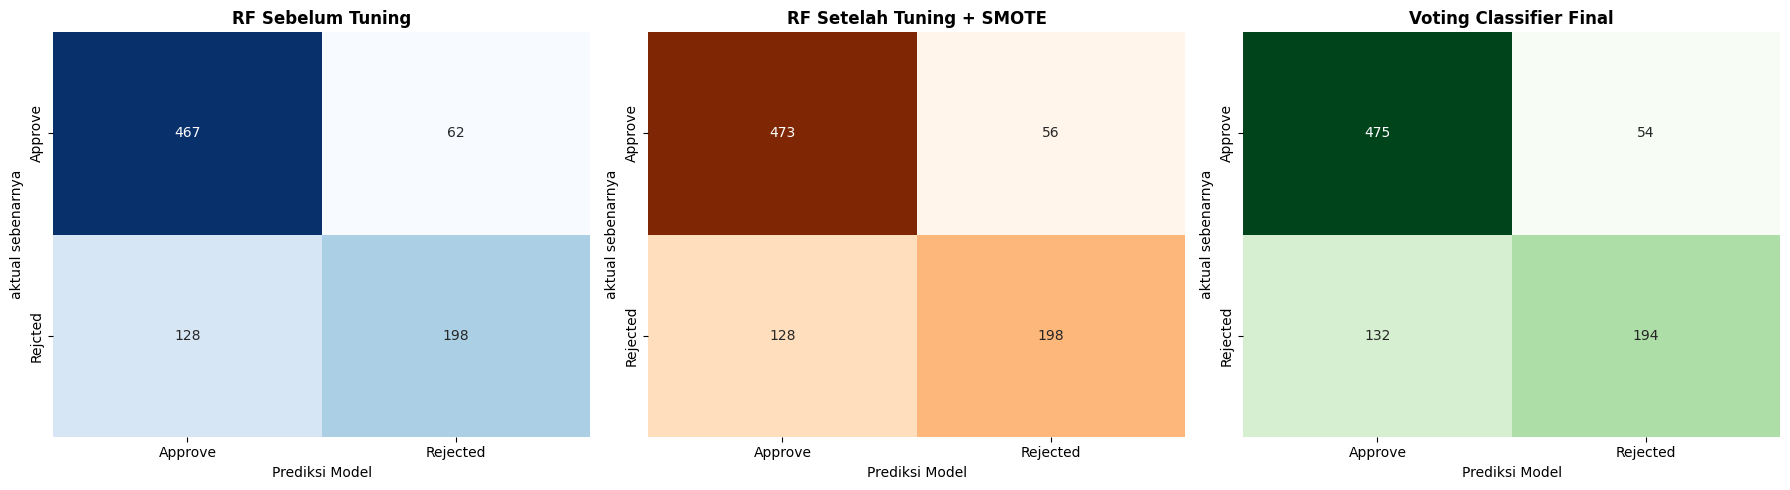

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# RF Sebelum Tuning (Baseline)
cm_base = confusion_matrix(y_test, pipeline_rf.predict(X_test))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Approve', 'Rejected'], yticklabels=['Approve', 'Rejcted'])
axes[0].set_title('RF Sebelum Tuning', fontsize=12, fontweight='bold')

# RF setelah Tuning + SMOTE
cm_tuned_rf = confusion_matrix(y_test, grid_search.best_estimator_.predict(X_test))
sns.heatmap(cm_tuned_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False,
            xticklabels=['Approve', 'Rejected'], yticklabels=['Approve', 'Rejected'])
axes[1].set_title('RF Setelah Tuning + SMOTE', fontsize=12, fontweight='bold')

# Voting Classifier Final
cm_voting = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar=False,
            xticklabels=['Approve', 'Rejected'], yticklabels=['Approve', 'Rejected'])
axes[2].set_title('Voting Classifier Final', fontsize=12, fontweight='bold')


for ax in axes:
  ax.set_ylabel('aktual sebenarnya')
  ax.set_xlabel('Prediksi Model')

plt.tight_layout()
plt.show()


**Bar Chart Sakti: Perbandingan "Akurasi" vs "Recall"**

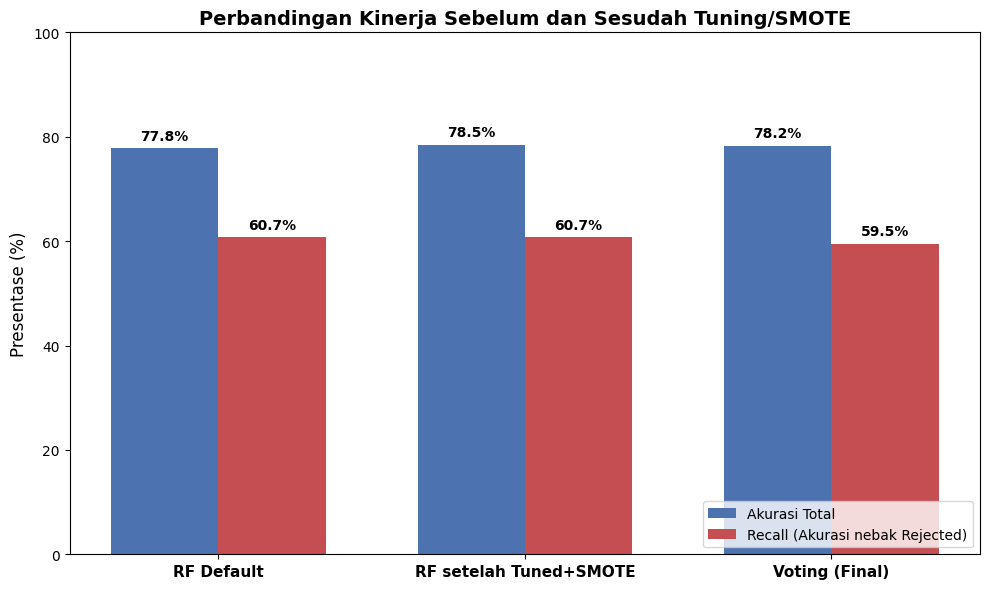

In [25]:
from sklearn.metrics import recall_score, accuracy_score
import numpy as np

#label sumbu x
labels = ['RF Default', 'RF setelah Tuned+SMOTE', 'Voting (Final)']

# Kumpulin nilai Akurasi
acc_scores = [
    accuracy_score(y_test, pipeline_rf.predict(X_test)) * 100,
    accuracy_score(y_test, grid_search.best_estimator_.predict(X_test)) * 100,
    accuracy_score(y_test, y_pred_final) * 100
]

# Kumpulin nilai Recall khusus kelas 1 (Mendeteksi orang yang Gagal Bayar)
recall_scores = [
    recall_score(y_test, pipeline_rf.predict(X_test), pos_label=1) * 100,
    recall_score(y_test, grid_search.best_estimator_.predict(X_test), pos_label=1) * 100,
    recall_score(y_test, y_pred_final, pos_label=1) * 100
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, acc_scores, width, label='Akurasi Total', color='#4C72B0')
rects2 = ax.bar(x + width/2, recall_scores, width, label='Recall (Akurasi nebak Rejected)', color='#C44E52')

ax.set_ylabel('Presentase (%)', fontsize=12)
ax.set_title('Perbandingan Kinerja Sebelum dan Sesudah Tuning/SMOTE', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0, 100)


# Tambah teks angka persis di atas batang grafik
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + '%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9), textcoords = 'offset points', fontweight = 'bold')


plt.tight_layout()
plt.show()

**Titik Puncak Performa**

Dari grafik biru (Akurasi Total), ini menjelasin kalau RF setelah Tuned+SMOTE adalah model yang ngasih performa paling tinggi (78.5%). Artinya, proses Hyperparameter Tuning yang dilakukan pada penelitian kali ini berhasil nge-optimasi model Random Forest default yang awalnya cuma 77.8%

**Kenapa Recall-nya Stagnan di 60.7%?**

Ini menunjukkan karakteristik dari dataset UMKM Bekasi itu sendiri. Batas maksimal informasi (fitur seperti umur, omset, tenor) yang bisa dipelajari algoritma untuk membedakan nasabah macet dan lancar memang berada di kisaran 60%. Artinya, sisa 40% nasabah gagal bayar memiliki profil data yang sangat mirip dengan nasabah lancar. Meskipun begitu, kombinasi Tuning+SMOTE terbukti tetap menguntungkan karena berhasil menaikkan Akurasi Total ke 78.5% tanpa mengorbankan nilai Recall sama sekali

**Kenapa Voting (Final) Recall-nya Malah Turun Dikit (59.5%)?**

Karena sistem Voting Final yang  dipakai pada penelitian adalah 'Hard Voting' dengan 2 model (Genap). Ketika terjadi perbedaan pendapat antar model (misal Random Forest menebak Reject, tapi Bagging menebak Approved), sistem otomatis memenangkan kelas mayoritas atau kelas 0 (Approved). Akibatnya, model Voting Final ini sifatnya jauh lebih berhati-hati (konservatif) agar tidak salah menolak nasabah yang sebenarnya bagus, meskipun efek sampingnya nilai Recall (mendeteksi Reject) turun sedikit sekitar 1%

# **Update Feature Importance dari Model Hasil Tuning**

/tmp/ipykernel_2723/807176487.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_urut_tuned, y=fitur_urut_tuned, palette='magma')


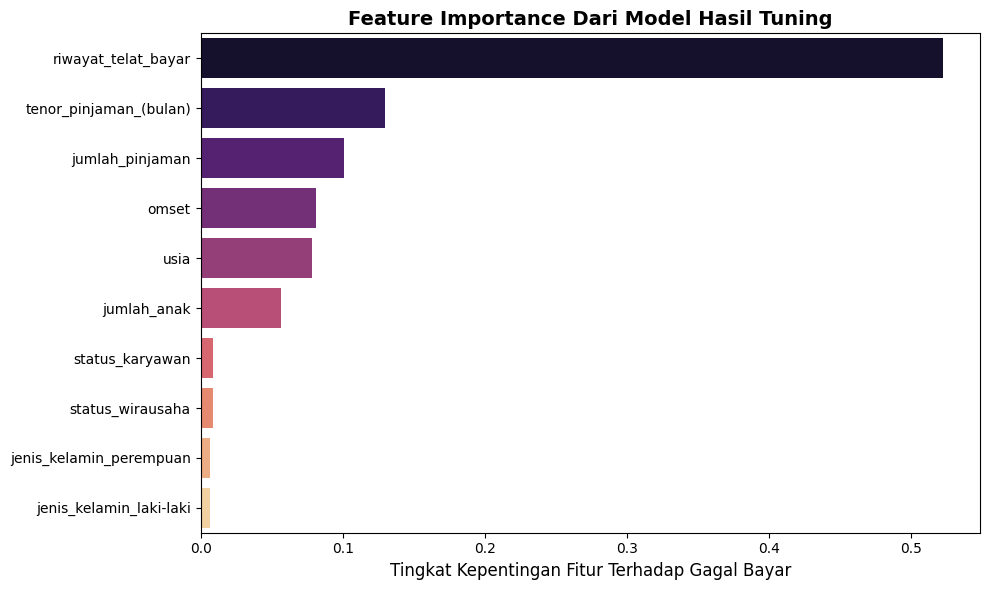

In [26]:
# Ekstrak nama fitur dari preprocessor (Sama kayak cara sebelumnya)
preprocessor_step = pipeline_voting_final.named_steps['preprocessor']
ohe_step = preprocessor_step.transformers_[1][1].named_steps['onehot']
cat_cols = ohe_step.get_feature_names_out(categorical_features)
semua_fitur = np.concatenate([numeric_features, cat_cols])

# Ambil model rf_terbaik langsung dari hasil Grid Search yang sudah dijalankan sebelumnya
rf_terbaik = grid_search.best_estimator_.named_steps['model']
importances_tuned = rf_terbaik.feature_importances_

# Urutkan dari yang paling gede
indices_tuned = np.argsort(importances_tuned)[::-1]
fitur_urut_tuned = semua_fitur[indices_tuned]
importance_urut_tuned = importances_tuned[indices_tuned]

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_urut_tuned, y=fitur_urut_tuned, palette='magma')
plt.title('Feature Importance Dari Model Hasil Tuning', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan Fitur Terhadap Gagal Bayar', fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
import joblib
from google.colab import files

# Simpan model Voting Classifier Final combinasi RF + BAGGING = voting
joblib.dump(pipeline_voting_final, 'model_kredit_usaha_rakyat.pkl')

#Download file
files.download('model_kredit_usaha_rakyat.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>